In [1]:
import glob
import os
import socket
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from itertools import product
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
machine_name = socket.gethostname()
if 'huwx' in machine_name:
    data_folder = '/home/huwxx/user_shared/data/PJM/'
elif 'l25001' in machine_name or 'Jack' in machine_name:
    data_folder = '../data/pjm/data-miner-2/'
else:
    raise ValueError(f"Unknown machine: {machine_name}. Define data_folder manually.")

actual_files = sorted(glob.glob(os.path.join(data_folder, "load_actual_*.csv")))
if not actual_files:
    raise FileNotFoundError(f"No files found in {data_folder}")

df = pd.concat([pd.read_csv(f) for f in actual_files], ignore_index=True)
df["datetime_beginning_ept"] = pd.to_datetime(df["datetime_beginning_ept"], format="%m/%d/%Y %I:%M:%S %p")
df = df.sort_values("datetime_beginning_ept").reset_index(drop=True)

##### Defines a function to filter the DataFrame for EST (roughly Nov 9 to Mar 6) and checks for hourly data consistency.

In [ ]:
def filter_winter_season(df, start_month_day="11-9", end_month_day="03-06", zone_col='zone'):
    df = df.copy()
    df['year'] = df['datetime_beginning_ept'].dt.year
    df['month_day'] = df['datetime_beginning_ept'].dt.strftime('%m-%d')
    mask = []
    for y in df['year'].unique():
        start = pd.to_datetime(f"{y}-{start_month_day}")
        end = pd.to_datetime(f"{y+1}-{end_month_day}")
        season_df = df[(df['datetime_beginning_ept'] >= start) & (df['datetime_beginning_ept'] <= end)]
        
        for zone, zone_df in season_df.groupby(zone_col):
            zone_df = zone_df.sort_values('datetime_beginning_ept')
            time_diff = zone_df['datetime_beginning_ept'].drop_duplicates().diff().dropna()
            if not (time_diff == pd.Timedelta(hours=1)).all():
                raise ValueError(f"Non-hourly or missing data detected in winter {y}-{y+1} for zone {zone}")
        
        mask.append((df['datetime_beginning_ept'] >= start) & (df['datetime_beginning_ept'] <= end))
    
    full_mask = np.logical_or.reduce(mask)
    return df[full_mask].drop(columns=['year', 'month_day'])

df = filter_winter_season(df)

##### Creates a custom Dataset class for autoregressive modeling, handling historical and future load data for a specific area and time range. Initializes training, validation, and test datasets with specific winter time ranges for the EKPC load area. Sets up DataLoaders for batching and shuffling (only for training) the datasets.

In [4]:
class ARDataset(Dataset):
    def __init__(self, df, n_historical, n_future, start_time, end_time):
        self.df = df[(df.load_area == "EKPC") &
                     (df.datetime_beginning_ept >= pd.to_datetime(start_time)) &
                     (df.datetime_beginning_ept <= pd.to_datetime(end_time))].reset_index(drop=True)
        if len(self.df) < n_historical + n_future:
            raise ValueError(f"Data from {start_time} to {end_time} too short for {n_historical}+{n_future} hours.")
        self.n_historical = n_historical
        self.n_future = n_future
        self.valid_indices = list(range(n_historical, len(self.df) - n_future))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        i = self.valid_indices[idx]
        x = self.df.mw.iloc[i - self.n_historical:i].values.astype(np.float32)
        y = self.df.mw.iloc[i + 1:i + 1 + self.n_future].values.astype(np.float32)
        x_tensor = torch.tensor(np.log1p(x)).unsqueeze(-1)
        y_tensor = torch.tensor(np.log1p(y)).unsqueeze(-1) 
        return x_tensor, y_tensor

n_historical = 48
n_future = 24
batch_size = 16

train_ds = ARDataset(df, n_historical, n_future, "2014-11-14", "2020-03-01")  
val_ds   = ARDataset(df, n_historical, n_future, "2020-11-14", "2022-03-01")
test_ds  = ARDataset(df, n_historical, n_future, "2022-11-14", "2024-03-01") 

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_dl  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

##### Defines an LSTM neural network model with configurable layers and hidden sizes for time series prediction.

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_size=64, num_layers=2, output_seq_len=24):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_seq_len)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out.unsqueeze(-1)

##### Defines a training loop with early stopping, optimizing the model using Adam and MSE loss, and tracking the best validation performance. Prepares for grid search over hidden sizes, layer counts, and learning rates, limiting to 20 random trials.

In [11]:
def train_model(model, train_dl, val_dl, n_epochs, lr, patience=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                val_losses.append(loss_fn(model(x), y).item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return best_state, best_val_loss

##### Iterates over random combinations of hyperparameters, trains models, and tracks the best configuration based on validation loss. Prints the best configuration, saves its state to a file, and writes the config details to a text file.

In [ ]:
hidden_sizes = [32, 64, 128, 256]
num_layers_list = [1, 2, 3]
learning_rates = [0.01, 0.005, 0.001, 0.0005, 0.0001]
n_trials = 20

best_val_loss = float('inf')
best_config = None
best_state_dict = None

configs = list(product(hidden_sizes, num_layers_list, learning_rates))
random.shuffle(configs)

for i, (hidden_size, num_layers, lr) in enumerate(configs[:n_trials]):
    print(f"\nTrial {i+1}/{n_trials}: hidden={hidden_size}, layers={num_layers}, lr={lr}")
    model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers).to(device)
    state_dict, val_loss = train_model(model, train_dl, val_dl, n_epochs=50, lr=lr)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = (hidden_size, num_layers, lr)
        best_state_dict = state_dict

print(f"\nBest config: hidden={best_config[0]}, layers={best_config[1]}, lr={best_config[2]}, val_loss={best_val_loss:.4f}")
torch.save(best_state_dict, "best_lstm_model.pth")
with open("best_lstm_config.txt", "w") as f:
    f.write(f"hidden={best_config[0]}, layers={best_config[1]}, lr={best_config[2]}, val_loss={best_val_loss:.4f}")

In [ ]:
with open("best_lstm_config.txt", "r") as f:
    config_text = f.read()
    hidden = int(re.search(r"hidden=(\d+)", config_text).group(1))
    layers = int(re.search(r"layers=(\d+)", config_text).group(1))

best_model = LSTMModel(hidden_size=hidden, num_layers=layers).to(device)
best_model.load_state_dict(torch.load("best_lstm_model.pth"))
best_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        pred = best_model(x).cpu().numpy()
        y_true.append(y.numpy())
        y_pred.append(pred)

y_true = np.expm1(np.concatenate(y_true).reshape(-1))
y_pred = np.expm1(np.concatenate(y_pred).reshape(-1))

## Specifically extracts and plots the 1-hour-lead forecasts


=== 1-Hour-Lead Forecast Metrics ===
MAE:  83.05 MW
MSE:  11661.12 MW^2
MAPE: 4.71%


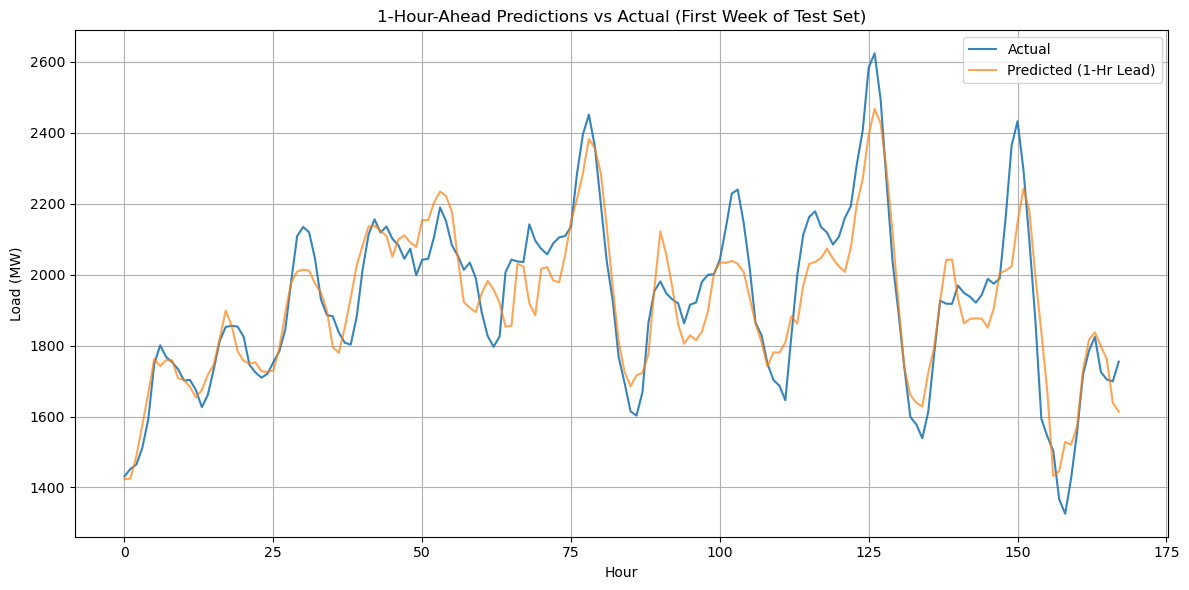

In [ ]:
y_true_1hr, y_pred_1hr = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        pred = best_model(x)
        
        one_hour_pred = pred[:, 0, :] 

        one_hour_true = y[:, 0, :]     

        y_pred_1hr.append(one_hour_pred.cpu().numpy())
        y_true_1hr.append(one_hour_true.cpu().numpy())

y_pred_1hr = np.expm1(np.concatenate(y_pred_1hr).reshape(-1))
y_true_1hr = np.expm1(np.concatenate(y_true_1hr).reshape(-1))

mae_1hr = mean_absolute_error(y_true_1hr, y_pred_1hr)
mse_1hr = mean_squared_error(y_true_1hr, y_pred_1hr)
mape_1hr = mean_absolute_percentage_error(y_true_1hr, y_pred_1hr) * 100

print("\n=== 1-Hour-Lead Forecast Metrics ===")
print(f"MAE:  {mae_1hr:.2f} MW")
print(f"MSE:  {mse_1hr:.2f} MW^2")
print(f"MAPE: {mape_1hr:.2f}%")


n_hours = 168
y_true_week_1hr = y_true_1hr[:n_hours]
y_pred_week_1hr = y_pred_1hr[:n_hours]

plt.figure(figsize=(12, 6))
plt.plot(y_true_week_1hr, label='Actual', alpha=0.9)
plt.plot(y_pred_week_1hr, label='Predicted (1-Hr Lead)', alpha=0.7)
plt.legend()
plt.grid(True)
plt.title("1-Hour-Ahead Predictions vs Actual (First Week of Test Set)")
plt.xlabel("Hour")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()